# 1. 문제 정의
- 버섯 데이터의 특성들을 활용하여 해당 버섯이 독인지 식용인지 분류
- 결정트리 모델을 시각화 해보자
- 특성 선택(Feature Selection)을 진행해보자

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# train_test_split : 데이터 랜덤 분리 클래스
from sklearn.model_selection import train_test_split

# DecisionTreeClassifier : 결정트리 분류 모델 클래스
from sklearn.tree import DecisionTreeClassifier

# 2. 데이터 수집
- csv 파일 업로드
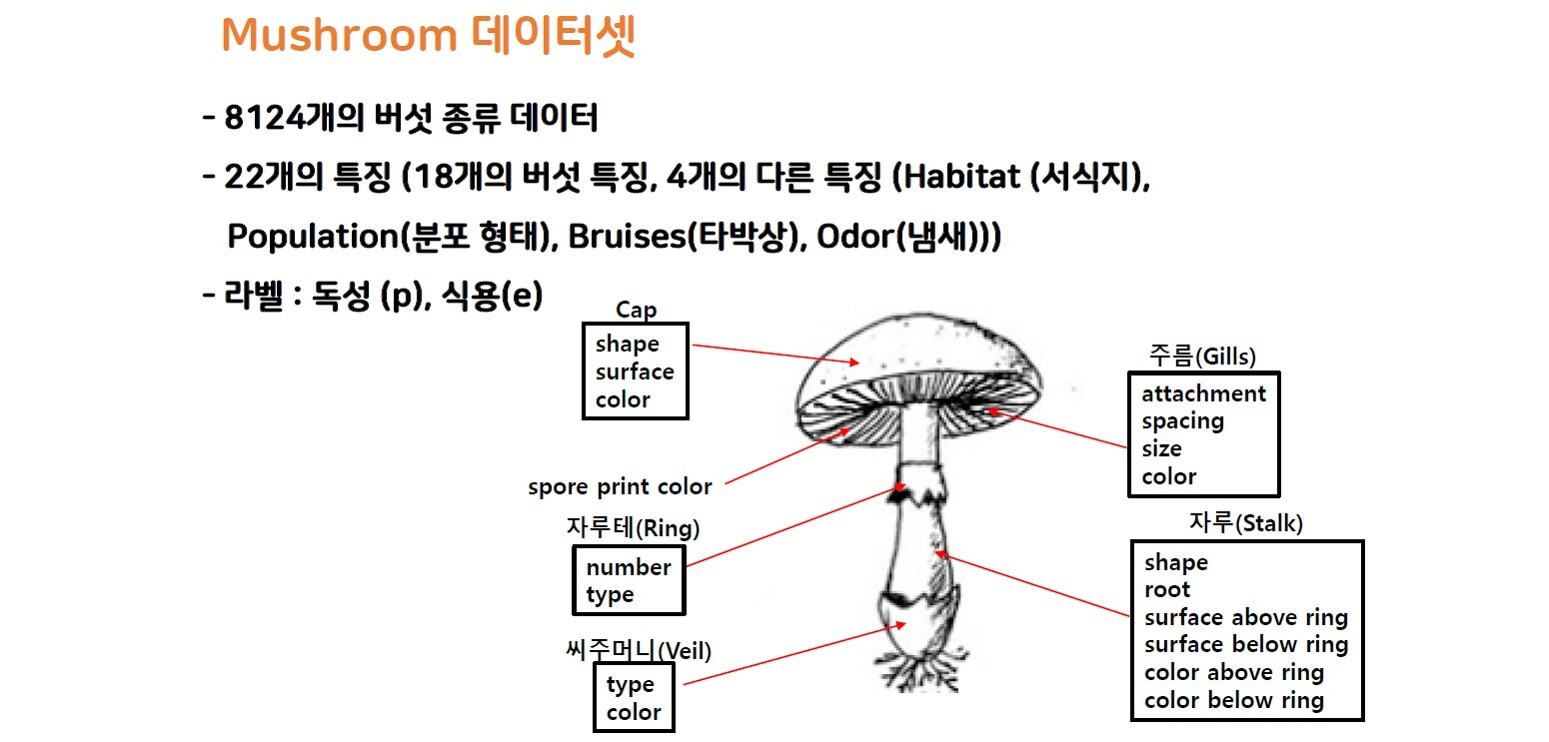

In [3]:
df = pd.read_csv('data/mushroom.csv')

# 2. 전체 컬럼, 행의 숫자 파악
# 3. 데이터 타입 확인
# 4. 결측치 있는지 확인
# df.isna().count()
df.info()

# poisonous : 정답 컬럼 (p는 독버섯, e는 식용버섯)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   poisonous                 8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

# 3. 데이터 전처리
- 학습용이라 따로 없음

# 4. 탐색적 데이터 분석
- 기술통계
- 시각화

In [5]:
df.describe()

# 문자형 데이터는 수치형 데이터처럼 평균이나 표준편차 등이 아닌 다른 통계치가 나옹ㅁ
 # top : 해당 컬럼에서 가장 많은 수를 차지하는 데이터 (최빈값) 
 # freq : top의 빈도수 (개수)

,poisonous,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


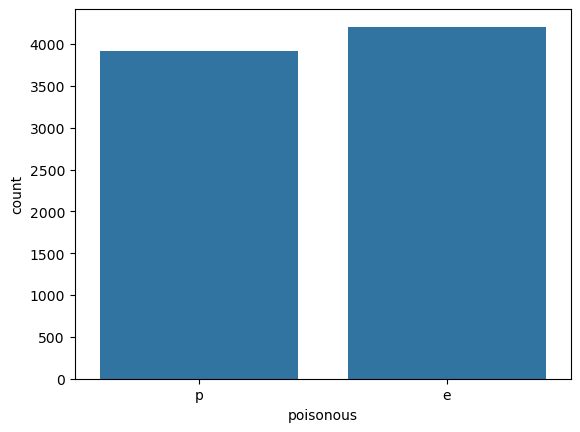

In [6]:
# countplot : bar 형태로 정답 데이터의 수를 확인!
sns.countplot(data=df,
             x='poisonous'
             );

# 정답 컬럼의 p(독성), e(식용) 비율이 편향되어 있지 않은 것 확인!

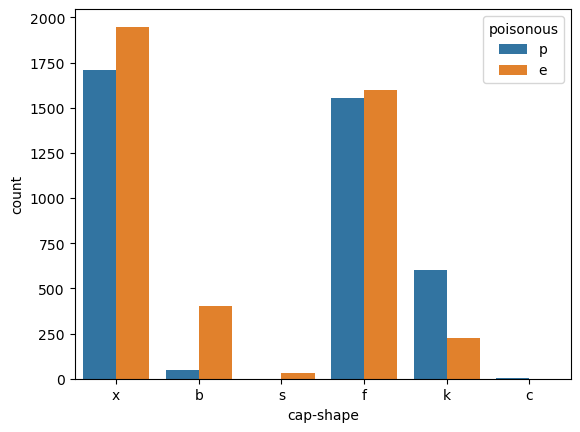

In [7]:
sns.countplot(data=df,
             x='cap-shape',
             hue='poisonous'  # hue: 해당 컬럼의 unique 값들이 들어가서 카운팅되고 범례도 출력됨
             );

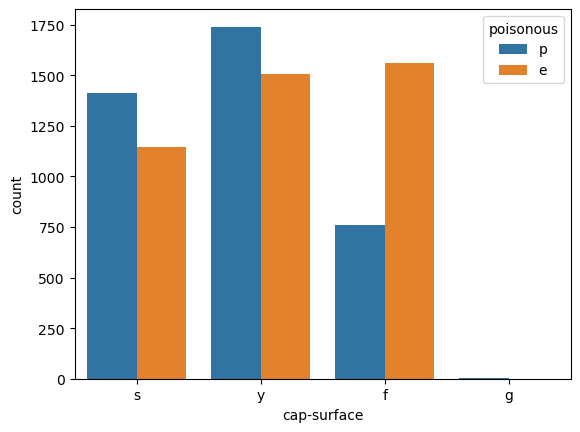

In [9]:
# 버섯 표면 성질에 따른 독성, 식용 데이터 분포 
sns.countplot(data=df,
             x='cap-surface',
             hue='poisonous'
             );

# 5. 모델링 (모델 선택, 모델 튜닝 및 학습, 모델 평가)

In [18]:
# 데이터를 X, y로 분리
X = df.iloc[:, 1:]  # X = df.loc[:, 'cap-shape':]
y = df.iloc[:, 0]   # y = df.loc[:, 'poisonous']
print(X.shape)
print(y.shape)

(8124, 22)
(8124,)


### 문자형 데이터 인코딩
- **레이블 인코딩 (Lable Encoding)**
  - 특정 문자 데이터를 0, 1, 2.. 순으로 정수 간격으로 매핑하는 방식
  - 간단하고 직관적이나 숫자의 크고 작음에 의해 거리나 수치기반 모델에 적용했을 때 정확한 예측이 힘들 수 있음
- **원 핫 인코딩 (One-hot Encoding)**
  - 하나만, 활성화하는 인코딩
  - 특정 컬럼의 유니크 값에 대한 더미 컬럼들을 만들어 데이터가 있는 자리에 1로 표시
  - 컴퓨터는 모든 데이터를 2진수로 처리하기 때문에 기계가 받아들이기 쉬운 형태, 수치의 크고 작음에 대한 특성이 없음
  - 데이터 종류가 많을 경우 그만큼 더미 컬럼들이 많이 만들어져 메모리 소모가 클 수 있음 

In [20]:
X['cap-shape'].value_counts()

cap-shape
x    3656
f    3152
k     828
b     452
s      32
c       4
Name: count, dtype: int64

### **레이블 인코딩**

In [21]:
# map 함수 사용 (key값의 데이터를 value 값으로 변환)
X['cap-shape'].map({'x':0, 'f':1, 'k':2, 'b':3, 's':4, 'c':5})

0       0
1       0
2       3
3       0
4       0
       ..
8119    2
8120    0
8121    1
8122    2
8123    0
Name: cap-shape, Length: 8124, dtype: int64

In [22]:
# 레이블 인코딩을 자동으로 진행해주는 레이블 인코더 임포트
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()        # 레이블 인코더 객체 생성
le.fit(X['cap-shape'])          # 레이블 인코더로 학습 (우리의 데이터 범위를 인지시켜주기)
labels = le.transform(X['cap-shape'])     # 학습된 인코더로 실제 정수값으로 변환
labels

array([5, 5, 0, ..., 2, 3, 5], shape=(8124,))

In [24]:
# 인코더가 변환한 값의 순서 확인 (인덱스 번호로 변환됨)
 # 영문은 a,b,c 순서 / 한글은 가,나,다 순서
le.classes_

array(['b', 'c', 'f', 'k', 's', 'x'], dtype=object)

### 여러개의 컬럼 동시에 레이블 인코딩 시키기

In [26]:
encoded_X = X.copy()  # 기존 데이터 복사해서 사용

le = LabelEncoder()

for col in encoded_X.columns:
    encoded_X[col] = le.fit_transform(encoded_X[col])  # fit_transform : fit과 transform 기능을 하나로 합친 함수

In [27]:
encoded_X.head()

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,5,2,4,1,6,1,0,1,4,0,...,2,7,7,0,2,1,4,2,3,5
1,5,2,9,1,0,1,0,0,4,0,...,2,7,7,0,2,1,4,3,2,1
2,0,2,8,1,3,1,0,0,5,0,...,2,7,7,0,2,1,4,3,2,3
3,5,3,8,1,6,1,0,1,5,0,...,2,7,7,0,2,1,4,2,3,5
4,5,2,3,0,5,1,1,0,4,1,...,2,7,7,0,2,1,0,3,0,1


### **원핫인코딩**

In [30]:
# dtype을 int로 설정하면 0, 1로 출력됨 (디폴트는 True, False로 출력)

temp = pd.get_dummies(X[['cap-shape']], dtype=int)
temp

,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x
0,0,0,0,0,0,1
1,0,0,0,0,0,1
2,1,0,0,0,0,0
3,0,0,0,0,0,1
4,0,0,0,0,0,1
...,...,...,...,...,...,...
8119,0,0,0,1,0,0
8120,0,0,0,0,0,1
8121,0,0,1,0,0,0
8122,0,0,0,1,0,0


In [31]:
# 데이터 프레임 전체 원핫인코딩
X_one_hot = pd.get_dummies(X, dtype=int)
X_one_hot

# 데이터프레임에 문자형, 수치형 섞여있으면 자동으로 문자형만 변환됨

,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,cap-surface_s,cap-surface_y,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,0,0,0,0,0,1,0,0,1,0,...,1,0,0,0,0,0,0,0,1,0
1,0,0,0,0,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
2,1,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,0
3,0,0,0,0,0,1,0,0,0,1,...,1,0,0,0,0,0,0,0,1,0
4,0,0,0,0,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,0,0,0,1,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
8120,0,0,0,0,0,1,0,0,1,0,...,0,1,0,0,0,1,0,0,0,0
8121,0,0,1,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
8122,0,0,0,1,0,0,0,0,0,1,...,0,1,0,0,0,1,0,0,0,0


In [32]:
# 학습 및 평가 데이터로 나누기 (train_test_split 사용)
X_train, X_test, y_train, y_test = train_test_split(
    X_one_hot, y,      # 문제, 정답 데이터
    test_size=0.3,     # 평가 데이터 비율 (0.3 = 30%)
    random_state=99,   # 데이터를 섞을 때 랜덤 시드값 설정
    stratify=y      # 정답 클래스의 비율을 train과 test에 동일하게 맞춤 (데이터 편향 줄이기)
)

In [34]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5686, 117)
(2438, 117)
(5686,)
(2438,)


In [35]:
# 결정 트리 모델 객체 생성
tree_model = DecisionTreeClassifier(
    max_depth=3,           # 트리의 최대 깊이 
    max_leaf_nodes=5,       # 최대 리프노드의 개수
    min_samples_leaf=50      # 리프 노드의 최소 데이터 개수
)

tree_model

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,50
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,5
,min_impurity_decrease,0.0
,class_weight,None


In [38]:
# 모델 학습
tree_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,50
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,5
,min_impurity_decrease,0.0
,class_weight,None


In [39]:
# 학습 데이터의 정확도
tree_model.score(X_train, y_train)

0.9693985226873022

In [40]:
# 평가 데이터의 정확도
tree_model.score(X_test, y_test)

0.9680065627563577

## 학습된 트리 모델의 내부 구조 시각화

In [41]:
!pip install graphviz

In [50]:
import graphviz
# export_graphviz : 트리를 그리기 위한 정보를 추출해주는 함수 
from sklearn.tree import export_graphviz

import os
os.environ["PATH"]+=os.pathsep+'C:/Program Files/Graphviz/bin/'

In [63]:
export_graphviz(
    tree_model,      # 학습된 모델 객체
    out_file='data/tree.dot',     # 파일명 및 저장경로 (dot: 그래프 출력 정보 파일)
    class_names=['식용', '독'],    # 클래스 명칭 설정
    feature_names=X_one_hot.columns,   # 컬럼명 지정 (one-hot인코딩 된 컬럼명)
    impurity=True,        # 지니불순도 출력 (False는 미출력)
    filled=True           # 클래스별 색상 구분 설정 
)

In [73]:
y_train.value_counts() # class_names의 순서

poisonous
e    2945
p    2741
Name: count, dtype: int64

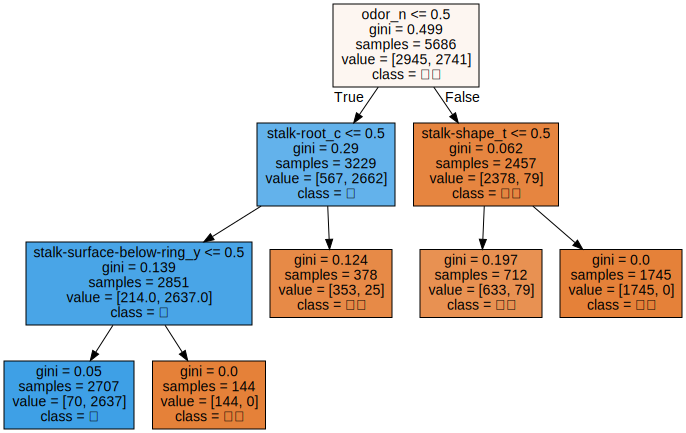

In [64]:
# dot 파일 불러오기
with open('data/tree.dot', encoding='utf-8') as f:
    dot_graph = f.read()

# 시각화
display(graphviz.Source(dot_graph))

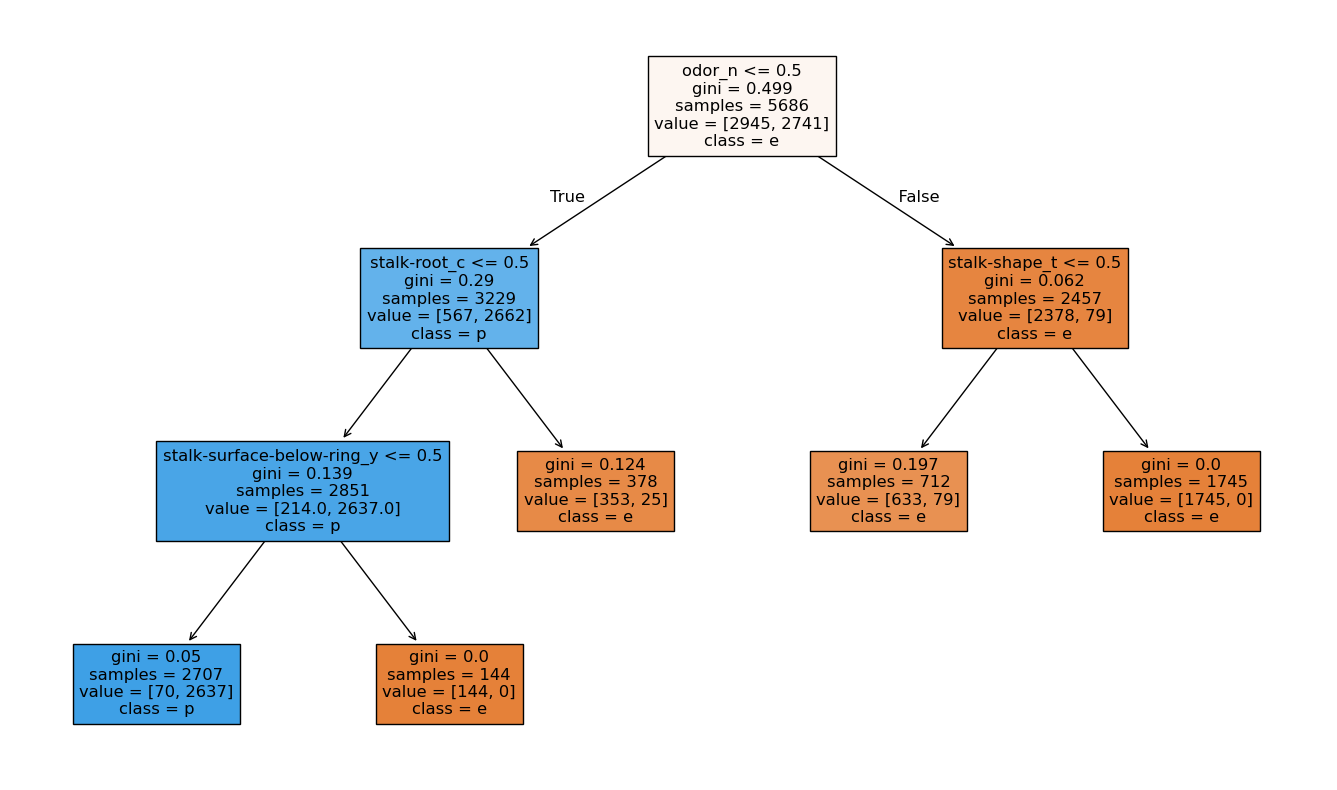

In [60]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(17, 10))
plot_tree(tree_model,
        class_names=['e', 'p'],
        feature_names=X_one_hot.columns,
        filled=True)
plt.show()

In [65]:
# 하이퍼파라미터 설정없이 모델 객체 만들기
tree_model2 = DecisionTreeClassifier()
tree_model2.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [66]:
tree_model2.score(X_train, y_train)

1.0

In [67]:
tree_model2.score(X_test, y_test)

1.0

In [68]:
export_graphviz(
    tree_model2,      # 학습된 모델 객체
    out_file='data/tree2.dot',     # 파일명 및 저장경로 (dot: 그래프 출력 정보 파일)
    class_names=['식용', '독'],    # 클래스 명칭 설정
    feature_names=X_one_hot.columns,   # 컬럼명 지정 (one-hot인코딩 된 컬럼명)
    impurity=True,        # 지니불순도 출력 (False는 미출력)
    filled=True           # 클래스별 색상 구분 설정 
)

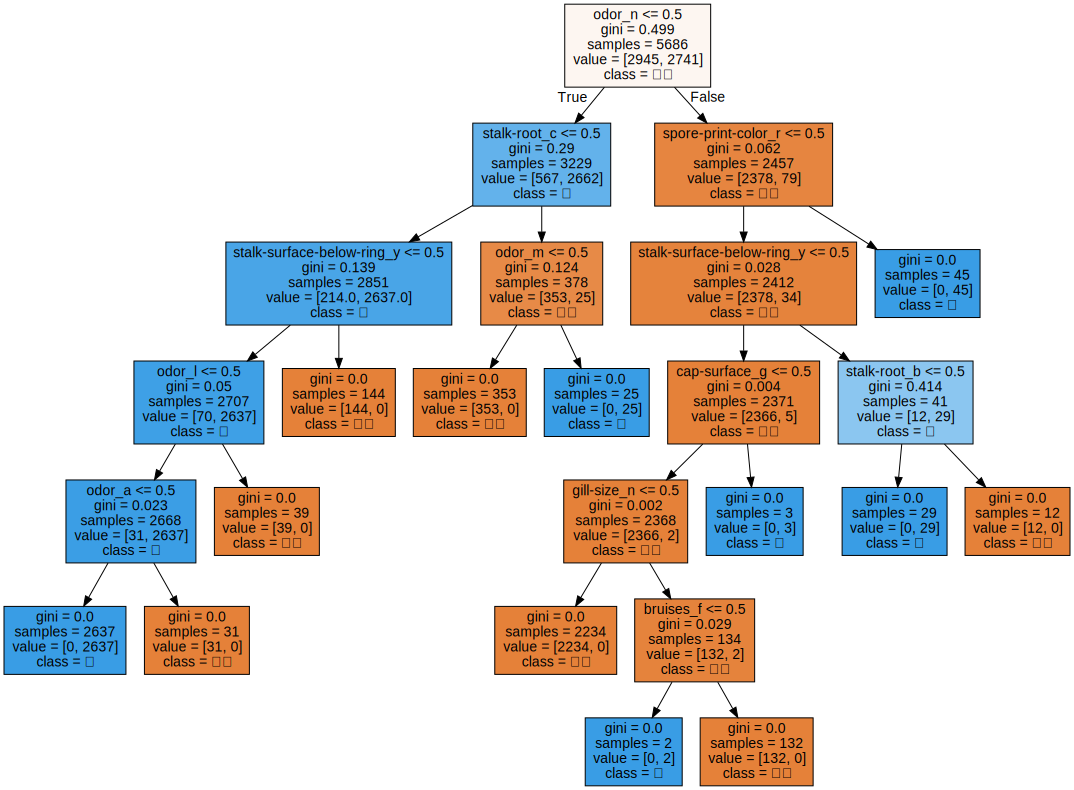

In [69]:
# dot 파일 불러오기
with open('data/tree2.dot', encoding='utf-8') as f:
    dot_graph2 = f.read()

# 시각화
display(graphviz.Source(dot_graph2))

## max_depth에 따른 train, test 데이터 정확도 비교

In [70]:
train_list, test_list = [], []   # 정확도가 담길 빈 리스트

# max_depth를 1~10까지 비교
for k in range(1, 11, 1):
    
    # 모델 생성
    tree_model3 = DecisionTreeClassifier(max_depth=k)
    # 모델 학습
    tree_model3.fit(X_train, y_train)

    # 학습한 모델의 정확도를 빈 리스트에 담기

    # train
    train_score = tree_model3.score(X_train, y_train)
    train_list.append(train_score)

    # test
    test_score = tree_model3.score(X_test, y_test)
    test_list.append(test_score)
    

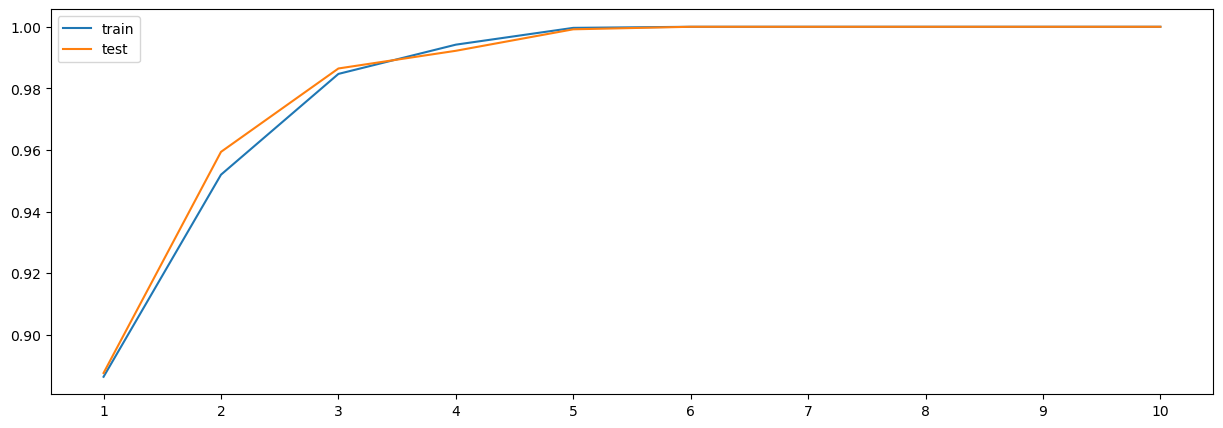

In [71]:
plt.figure(figsize=(15,5))
plt.plot(range(1, 11), train_list, label='train')
plt.plot(range(1, 11), test_list, label='test')

plt.xticks(range(1, 11))  # max_depth는 1부터 시작하므로 틱값도 1부터 설정
plt.legend()
plt.show()

## 특성 선택 (Feature Selection)
- 트리 모델이 정답을 예측함에 있어서 문제 데이터의 특성들의 중요도를 수치로 출력할 수 있음
- 즉 해당 특성이 모델의 정답 예측에 얼마만큼 기여했는지
   - 각 특성들은 0~1 사이의 실수값, 모든 특성의 중요도 합은 1이 됨
- 0이 나오는 컬럼은 정답 예측에 전혀 도움 되지 않는 특성
- 1이 나오는 컬럼은 완벽하게 정답을 예측해내는 특성
  - 1인 특성이 있다면, 모델이 정답 예측할 때 해당 특성만으로 판단했다는 뜻

In [75]:
# feature_importances_ : 학습된 트리모델에서 특성중요도 출력 

fi = tree_model.feature_importances_
print(fi)

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.696219   0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.00494901 0.         0.         0.19568622
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.10314577 0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0. 

In [76]:
len(fi)  # 원핫인코딩 된 특성의 개수

117

In [77]:
X_one_hot.columns     # 컬럼 순서

Index(['cap-shape_b', 'cap-shape_c', 'cap-shape_f', 'cap-shape_k',
       'cap-shape_s', 'cap-shape_x', 'cap-surface_f', 'cap-surface_g',
       'cap-surface_s', 'cap-surface_y',
       ...
       'population_s', 'population_v', 'population_y', 'habitat_d',
       'habitat_g', 'habitat_l', 'habitat_m', 'habitat_p', 'habitat_u',
       'habitat_w'],
      dtype='object', length=117)

In [81]:
# 데이터프레임화 시켜서 보기 편하게 출력
fi_df = pd.DataFrame(fi, index=X_one_hot.columns, columns=['특성 중요도'])
fi_df

,특성 중요도
cap-shape_b,0.0
cap-shape_c,0.0
cap-shape_f,0.0
cap-shape_k,0.0
cap-shape_s,0.0
...,...
habitat_l,0.0
habitat_m,0.0
habitat_p,0.0
habitat_u,0.0


In [83]:
# 내림차순 정렬
fi_df.sort_values(by='특성 중요도', ascending=False, inplace=True) # inplace 원본데이터 수정해라
fi_df

,특성 중요도
odor_n,0.696219
stalk-root_c,0.195686
stalk-surface-below-ring_y,0.103146
stalk-shape_t,0.004949
cap-shape_b,0.000000
...,...
gill-size_b,0.000000
gill-spacing_w,0.000000
gill-spacing_c,0.000000
gill-attachment_f,0.000000


- tree모델 내부 시각화 표를 보면 가장 중요도 높은 col을 고려해서 분류한 것으로 확인
- tree모델은 중요도 높은 (정답 분류하는데 중요한) 특성을 먼저 고려해 분기시켜주어야 가장 효율적으로 분류할 수 있음
- 현재 데이터는 ordor_n 컬럼이 약 69% 중요도를 차지, 3개의 특성만으로 99%의 중요도를 채우기 때문에 모델이 패턴을 쉽게 학습했음